# CatBoost con Filtrado por Información Mutua (Columnas Originales)

En este notebook se aplicará un enfoque híbrido:
1. **Filtrado estadístico**: Se usa Información Mutua (Mutual Information) para identificar variables relevantes
2. **Columnas sin codificar**: En lugar de usar One-Hot Encoding, se incluyen las columnas originales completas
3. **CatBoost nativo**: Se pasa el dataset con variables categóricas originales a CatBoost

**Ventaja de MI**: A diferencia de Chi-Cuadrado, la Información Mutua puede capturar relaciones no lineales y trabaja bien con tanto variables categóricas como numéricas.

In [65]:
import pandas as pd
import os
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
# Cargar el dataset
filename = '251111_hospital.csv'
possible_paths = [filename, os.path.join('Exam_2025', filename)]

file_path = None
for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        break

if file_path:
    print(f"Cargando archivo desde: {file_path}")
    df = pd.read_csv(file_path, sep='|')
    print(f"Dimensiones del dataset: {df.shape}")
    
    # Eliminar duplicados
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        print(f"Se encontraron {duplicates} filas duplicadas. Eliminándolas...")
        df = df.drop_duplicates()
        print(f"Dimensiones después de eliminar duplicados: {df.shape}")
    
    display(df.head())
else:
    print(f"Error: No se encontró el archivo {filename}.")

Cargando archivo desde: 251111_hospital.csv
Dimensiones del dataset: (4772, 22)
Se encontraron 2 filas duplicadas. Eliminándolas...
Dimensiones después de eliminar duplicados: (4770, 22)


,periodo,periodo_estudio,paridad,edad_madre,nacionalidad,estado_civil_madre,lugar_control_comuna,embarazo_controlado,embarazo_gemelar,lugar_parto,...,condicion_rn,sexo_rn,peso_nacimiento,edad_gestacional,antropometria,apgar_1min,apgar_5min,hospitalizado,lm_inmediato,acompanante
0,10-2020,PANDEMICO,PRIMIPARA,33,CHILENA,CONVIVIENTE,COLTAUCO,CONTROLADO,NO,PARTO HOSP,...,NACIDO VIVO,MASCULINO,4085,41,AEG,3,7,NO,NO,NO
1,10-2020,PANDEMICO,MULTIPARA,22,CHILENA,SOLTERA,RANCAGUA,CONTROLADO,NO,PARTO HOSP,...,NACIDO VIVO,FEMENINO,2660,37,AEG,6,8,NO,NO,NO
2,12-2020,PANDEMICO,MULTIPARA,37,CHILENA,CONVIVIENTE,RENGO,CONTROLADO,SI,PARTO HOSP,...,NACIDO VIVO,FEMENINO,2750,35,AEG,7,8,NO,NO,NO
3,11-2020,PANDEMICO,MULTIPARA,40,CHILENA,CONVIVIENTE,RENGO,CONTROLADO,SI,PARTO HOSP,...,NACIDO VIVO,FEMENINO,2485,36,AEG,7,8,NO,NO,NO
4,02-2021,PANDEMICO,MULTIPARA,33,CHILENA,CASADA,RANCAGUA,CONTROLADO,SI,PARTO HOSP,...,NACIDO VIVO,FEMENINO,2810,38,AEG,7,8,NO,NO,NO


In [67]:
# Eliminar la columna 'periodo' (no aporta información predictiva)
if 'periodo' in df.columns:
    df = df.drop(columns=['periodo'])
    print("Columna 'periodo' eliminada.")

# Definir variable objetivo y características
target_col = 'periodo_estudio'
X = df.drop(columns=[target_col])
y = df[target_col]

# Codificar la variable objetivo
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"Clases objetivo: {le_target.classes_}")

# Separar columnas numéricas y categóricas
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nVariables Categóricas ({len(cat_cols)}): {cat_cols}")
print(f"Variables Numéricas ({len(num_cols)}): {num_cols}")

Columna 'periodo' eliminada.
Clases objetivo: ['PANDEMICO' 'PREPANDEMICO']

Variables Categóricas (15): ['paridad', 'nacionalidad', 'estado_civil_madre', 'lugar_control_comuna', 'embarazo_controlado', 'embarazo_gemelar', 'lugar_parto', 'tipo_parto', 'tipo_cesarea', 'condicion_rn', 'sexo_rn', 'antropometria', 'hospitalizado', 'lm_inmediato', 'acompanante']
Variables Numéricas (5): ['edad_madre', 'peso_nacimiento', 'edad_gestacional', 'apgar_1min', 'apgar_5min']


## Filtrado Estadístico con Información Mutua

### Información Mutua para Variables Categóricas
La Información Mutua mide la dependencia entre variables. A diferencia de Chi-Cuadrado, puede capturar relaciones no lineales.

In [87]:
# Para aplicar Mutual Information a variables categóricas, necesitamos codificarlas temporalmente
# Usaremos LabelEncoder para cada columna categórica
X_cat_encoded = X[cat_cols].copy()

# Label encoding para cada columna categórica
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_cat_encoded[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Calcular Información Mutua para variables categóricas
# discrete_features=True indica que todas son categóricas
mi_cat_scores = mutual_info_classif(
    X_cat_encoded, 
    y_encoded, 
    discrete_features=True,
    random_state=314
)

# Crear DataFrame con resultados
mi_cat_results = pd.DataFrame({
    'Feature': cat_cols,
    'MI_Score': mi_cat_scores
}).sort_values('MI_Score', ascending=False)

print("Información Mutua - Variables Categóricas:")
display(mi_cat_results)

# Filtrar variables categóricas con MI > umbral (usaremos 0.001 como umbral mínimo)
mi_threshold_cat = 0.001
significant_cat_features = mi_cat_results[mi_cat_results['MI_Score'] > mi_threshold_cat]['Feature'].tolist()
print(f"\nVariables categóricas significativas (MI > {mi_threshold_cat}): {len(significant_cat_features)}")
print(significant_cat_features)

Información Mutua - Variables Categóricas:


,Feature,MI_Score
3,lugar_control_comuna,0.042295
13,lm_inmediato,0.028570
8,tipo_cesarea,0.022845
14,acompanante,0.010857
4,embarazo_controlado,0.006350
1,nacionalidad,0.005068
12,hospitalizado,0.002989
2,estado_civil_madre,0.002523
7,tipo_parto,0.001084
0,paridad,0.000841



Variables categóricas significativas (MI > 0.001): 9
['lugar_control_comuna', 'lm_inmediato', 'tipo_cesarea', 'acompanante', 'embarazo_controlado', 'nacionalidad', 'hospitalizado', 'estado_civil_madre', 'tipo_parto']


### Información Mutua para Variables Numéricas
Se aplicará Mutual Information para identificar variables numéricas relevantes.

In [80]:
# Calcular Información Mutua para variables numéricas
# discrete_features=False indica que son continuas
mi_num_scores = mutual_info_classif(
    X[num_cols], 
    y_encoded, 
    discrete_features=False,
    random_state=314
)

# Crear DataFrame con resultados
mi_num_results = pd.DataFrame({
    'Feature': num_cols,
    'MI_Score': mi_num_scores
}).sort_values('MI_Score', ascending=False)

print("Información Mutua - Variables Numéricas:")
display(mi_num_results)

# Filtrar variables numéricas con MI > umbral
mi_threshold_num = 0.001
significant_num_features = mi_num_results[mi_num_results['MI_Score'] > mi_threshold_num]['Feature'].tolist()
print(f"\nVariables numéricas significativas (MI > {mi_threshold_num}): {significant_num_features}")

Información Mutua - Variables Numéricas:


,Feature,MI_Score
1,peso_nacimiento,0.013146
2,edad_gestacional,0.008441
4,apgar_5min,0.007080
3,apgar_1min,0.004830
0,edad_madre,0.002897



Variables numéricas significativas (MI > 0.001): ['peso_nacimiento', 'edad_gestacional', 'apgar_5min', 'apgar_1min', 'edad_madre']


### Visualización de Información Mutua

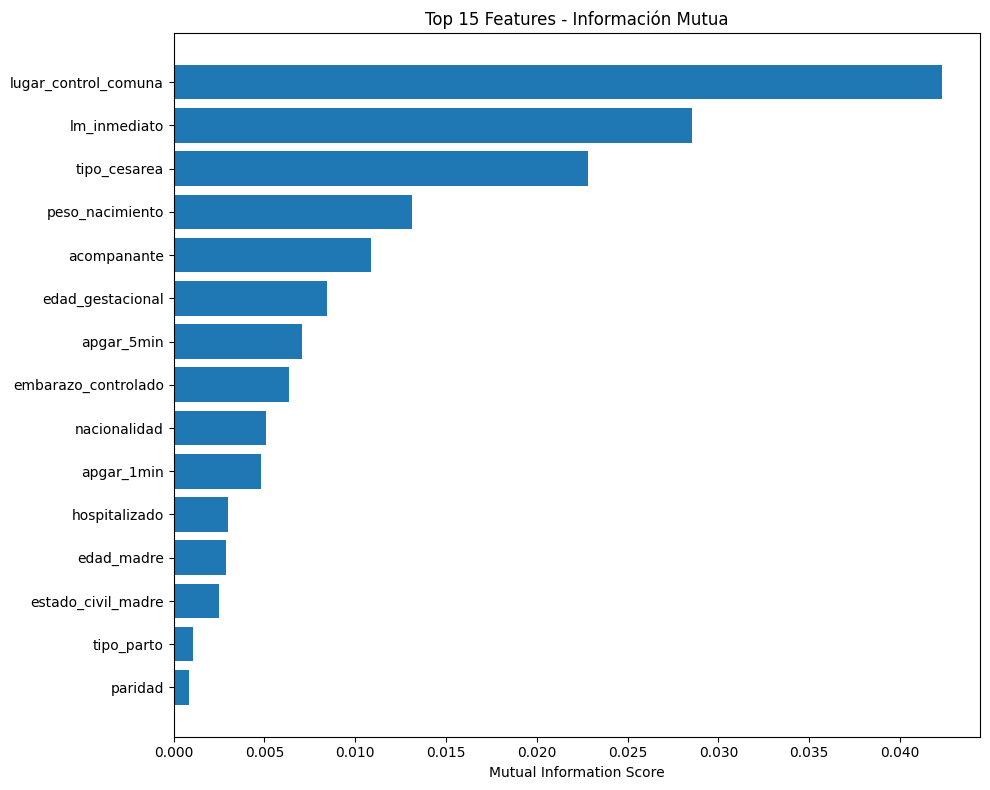


Total de features significativas: 13


In [81]:
# Combinar resultados para visualización
all_mi_results = pd.concat([
    mi_cat_results,
    mi_num_results
]).sort_values('MI_Score', ascending=False)

# Visualizar top 15 features
plt.figure(figsize=(10, 8))
top_15 = all_mi_results.head(15)
plt.barh(top_15['Feature'], top_15['MI_Score'])
plt.xlabel('Mutual Information Score')
plt.title('Top 15 Features - Información Mutua')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal de features significativas: {len(significant_cat_features) + len(significant_num_features)}")

## Construcción del Dataset Final

Se combinan:
- **Columnas categóricas originales** (sin codificar) que tienen MI significativa
- **Columnas numéricas** con MI significativa

In [88]:
# Construir el dataset final con columnas originales
final_features = significant_cat_features + significant_num_features

X_final = X[final_features].copy()

print(f"Dimensiones del dataset final: {X_final.shape}")
print(f"\nColumnas en el dataset final:")
print(f"  Categóricas ({len(significant_cat_features)}): {significant_cat_features}")
print(f"  Numéricas ({len(significant_num_features)}): {significant_num_features}")

display(X_final.head())

Dimensiones del dataset final: (4770, 14)

Columnas en el dataset final:
  Categóricas (9): ['lugar_control_comuna', 'lm_inmediato', 'tipo_cesarea', 'acompanante', 'embarazo_controlado', 'nacionalidad', 'hospitalizado', 'estado_civil_madre', 'tipo_parto']
  Numéricas (5): ['peso_nacimiento', 'edad_gestacional', 'apgar_5min', 'apgar_1min', 'edad_madre']


,lugar_control_comuna,lm_inmediato,tipo_cesarea,acompanante,embarazo_controlado,nacionalidad,hospitalizado,estado_civil_madre,tipo_parto,peso_nacimiento,edad_gestacional,apgar_5min,apgar_1min,edad_madre
0,COLTAUCO,NO,URGENCIA,NO,CONTROLADO,CHILENA,NO,CONVIVIENTE,CESAREA,4085,41,7,3,33
1,RANCAGUA,NO,URGENCIA,NO,CONTROLADO,CHILENA,NO,SOLTERA,CESAREA,2660,37,8,6,22
2,RENGO,NO,URGENCIA,NO,CONTROLADO,CHILENA,NO,CONVIVIENTE,CESAREA,2750,35,8,7,37
3,RENGO,NO,ELECTIVA,NO,CONTROLADO,CHILENA,NO,CONVIVIENTE,CESAREA,2485,36,8,7,40
4,RANCAGUA,NO,ELECTIVA,NO,CONTROLADO,CHILENA,NO,CASADA,CESAREA,2810,38,8,7,33


In [89]:
# Split data (85% train, 15% test, random_state=314)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_encoded, test_size=0.15, random_state=314
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (4054, 14)
Test set shape: (716, 14)


## Entrenamiento del Modelo CatBoost

CatBoost recibirá las columnas categóricas **sin codificar** y las manejará internamente.

In [90]:
# Especificar las columnas categóricas para CatBoost
cat_features_indices = [i for i, col in enumerate(final_features) if col in significant_cat_features]

print(f"Índices de features categóricas para CatBoost: {cat_features_indices}")
print(f"Columnas categóricas: {[final_features[i] for i in cat_features_indices]}")

# Entrenar modelo CatBoost
model = CatBoostClassifier(
    random_state=314,
    verbose=0,
    cat_features=cat_features_indices,
    learning_rate=0.05,
    task_type='CPU',


)

model.fit(X_train, y_train, eval_set=(X_test, y_test))
print("\nModelo entrenado exitosamente.")

Índices de features categóricas para CatBoost: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Columnas categóricas: ['lugar_control_comuna', 'lm_inmediato', 'tipo_cesarea', 'acompanante', 'embarazo_controlado', 'nacionalidad', 'hospitalizado', 'estado_civil_madre', 'tipo_parto']

Modelo entrenado exitosamente.


## Evaluación del Modelo

In [91]:
# Evaluar modelo
y_pred = model.predict(X_test)

# Métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7346368715083799
Precision: 0.7604166666666666
Recall: 0.8938775510204081
F1 Score: 0.8217636022514071


In [92]:
# Métrica de evaluación personalizada
s = (0.6*accuracy + 0.4*f1)**(1.3)
print(f"Métrica de evaluación: {s}")

Métrica de evaluación: 0.7113151962642854


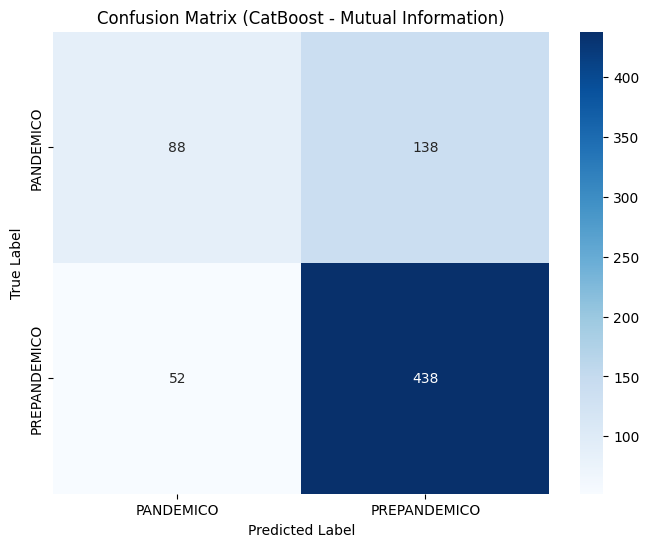

In [76]:
# Visualización: Matriz de Confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title('Confusion Matrix (CatBoost - Mutual Information)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()